In [1]:
from pathlib import Path
import pickle as pkl
import sys

dirpath_root = Path().resolve().parents[1]
sys.path.append(str(dirpath_root))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr

from analysis.ou_tuning import xr_utils
import analysis.ou_tuning.netpyne_res_parse_utils as parse_utils
import analysis.ou_tuning.data_proc_utils as proc_utils

In [2]:
exp_group = 'single_model1'
exp_name = 'model1_pulses_tc_itp4'

exp_name_sub = (
    'exp_t_5.0_7.0_mu_-2.32_sigma_2.81_d_200_T_1000_c_40_w_0.075_r_5000_0_t0_3000_jit_0'
)

dirpath_cfg = dirpath_root / 'exp_configs' / exp_group / exp_name
dirpath_res = dirpath_root / 'exp_results' / exp_group / exp_name / exp_name_sub

# Load sim results
fpath_pkl = dirpath_res / f'{exp_name}_data.pkl'
with open(fpath_pkl, 'rb') as fid:
    sim_res = pkl.load(fid)

--No graphics will be displayed.


In [8]:
S = parse_utils.get_pop_spikes(sim_res, 'PulseSeq', combine_cells=False, ms=True)
len(S)

100

Text(0, 0.5, 'Cell')

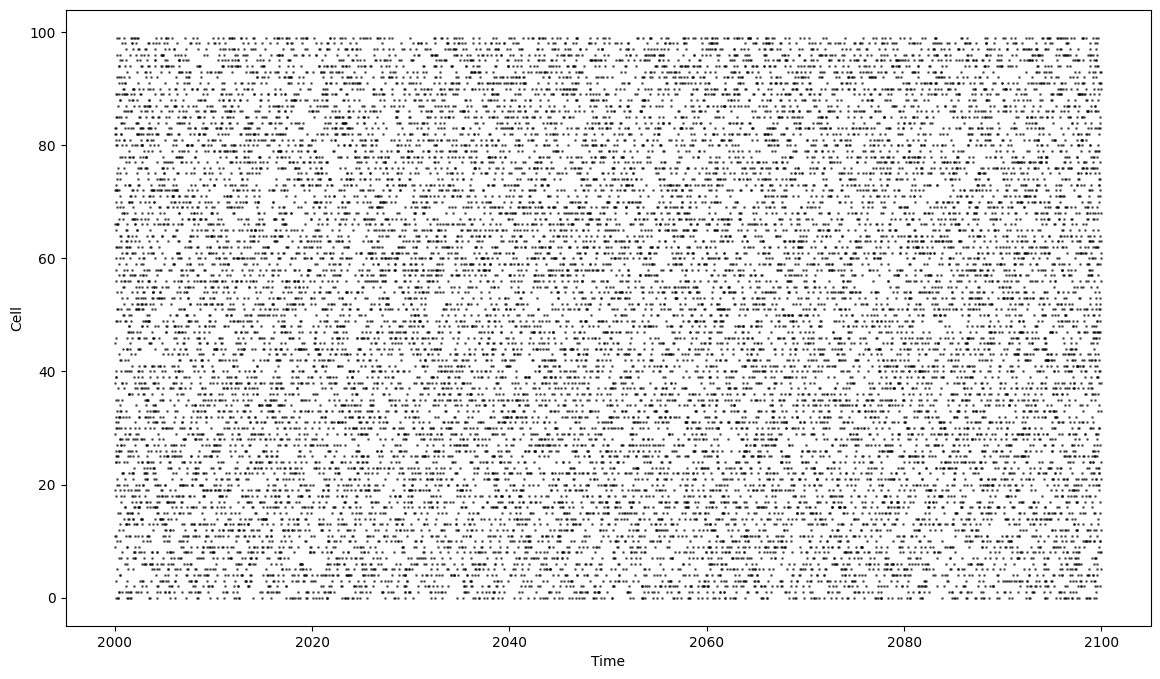

In [19]:
plt.figure(figsize=(14, 8))
for n in range(100):
    s = S[n]
    s = s[s < 2100]
    plt.plot(s, [n] * len(s), 'k.', alpha=0.5, markersize=2)
plt.xlabel('Time')
plt.ylabel('Cell')

In [4]:
W, tt, yy = parse_utils.get_lfp(sim_res)
W.shape

(20, 70000)

Text(0.5, 1.0, 'LFP')

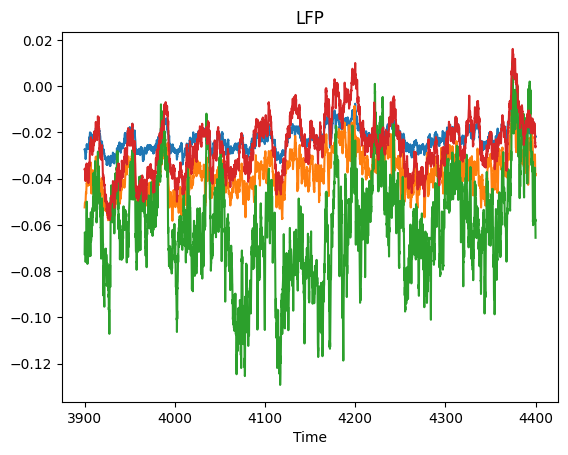

In [14]:
tmask = (tt > 3900) & (tt < 4400)

plt.figure()
for n in range(0, 20, 5):
    plt.plot(tt[tmask], W[n, :][tmask], label=f'y={yy[n]}')
    plt.xlabel('Time')
plt.title('LFP')
#plt.xlim(2500, 3500)